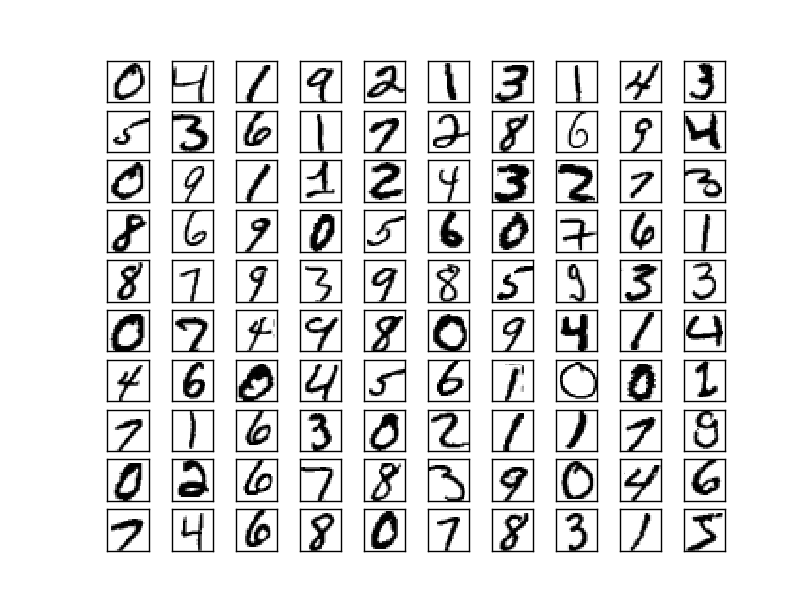

In [54]:
# julia language

using Images
using ImageFiltering
using ImageEdgeDetection

begin
    image = load("./assets/mnist_100_digits.png")

    # https://en.wikipedia.org/wiki/Normal_distribution
end

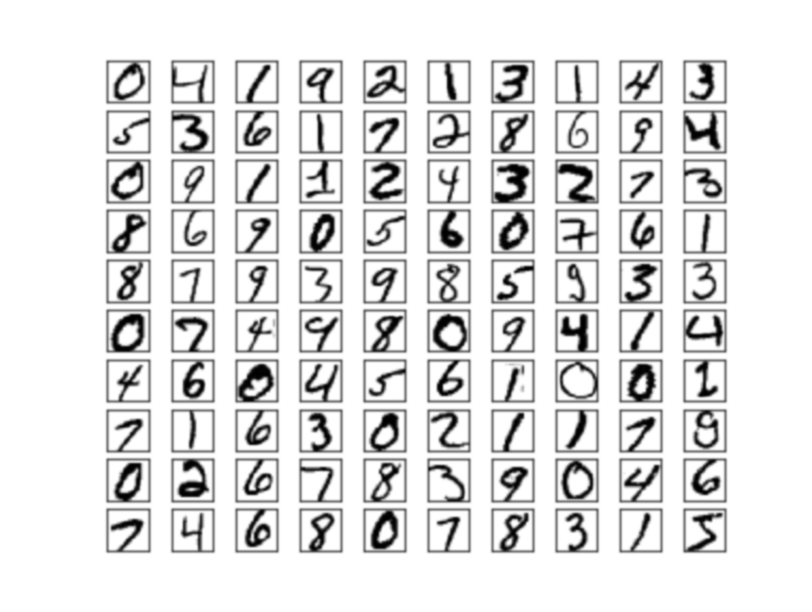

In [55]:
blurred = imfilter(image, Kernel.gaussian(1))

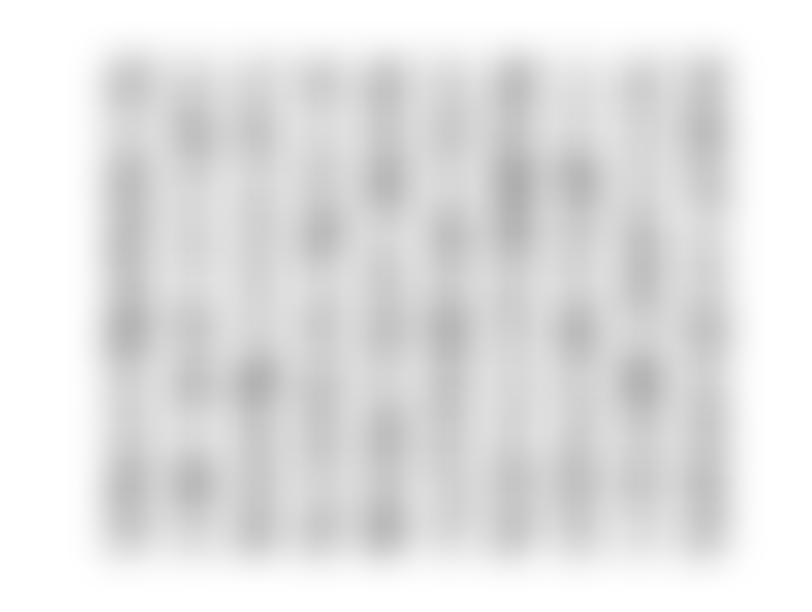

In [56]:
blurred = imfilter(image, Kernel.gaussian(20))

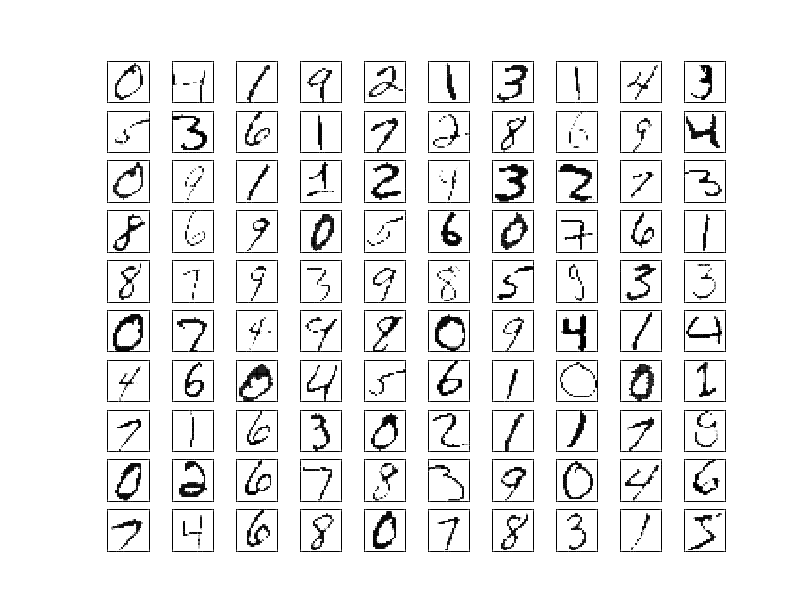

In [57]:
# sharpen edges Kernel
kernel = centered([
    -0.5 1.0 -0.5
    1.0 7.0 1.0
    -0.5 1.0 -0.5
])

img_float = RGB{Float32}.(image)
distinctEdges = imfilter(img_float, reflect(kernel))


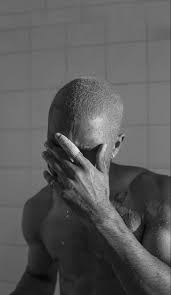

In [58]:
# img_copy = copy(image)

img_copy = load("./assets/download.jpeg")

img_size = size(img_copy) # (612, 812)

gray_img = copy(img_copy) 

for y_pixel in 1:img_size[1]
    for x_pixel in 1:img_size[2]
        pixel = gray_img[y_pixel, x_pixel]

        gray_val = (pixel.r * 0.299 + pixel.g * 0.587 + pixel.b * 0.114)

        gray_img[y_pixel, x_pixel] = Gray(gray_val)
    end
end

gray_img

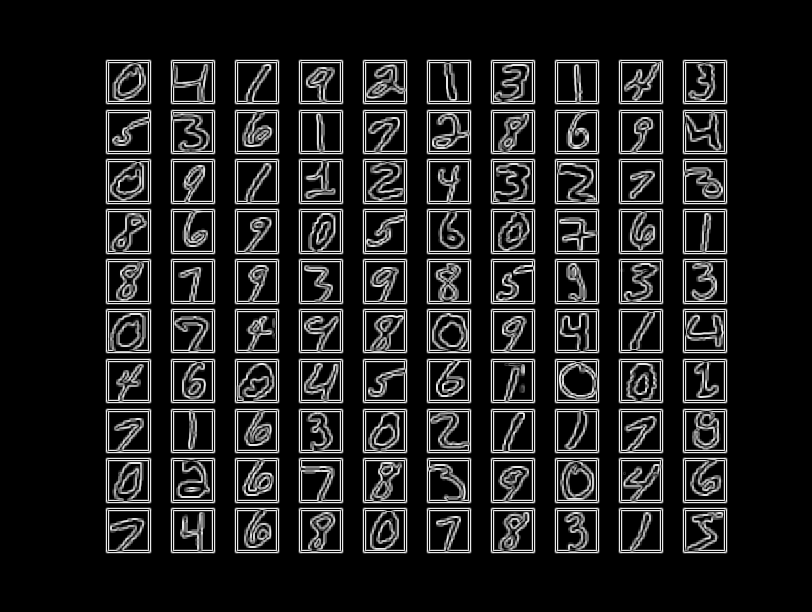

In [59]:
# sy, sx = Kernel.sobel()

# grad_x = imfilter(image, sx)

# grad_y = imfilter(image, sy)

# edgeImage = hypot.(grad_x, grad_y)



# edge_norm = edgeImage ./ maximum(edgeImage)

# Gray.(edge_norm)


gray_image = Gray.(image)

grad_x = imfilter(gray_image, sx)
grad_y = imfilter(gray_image, sy)

edgeImage = hypot.(grad_x, grad_y)

edge_norm = edgeImage ./ maximum(edgeImage)
Gray.(edge_norm)

# edgedImage = detect_edges(image, sobel())

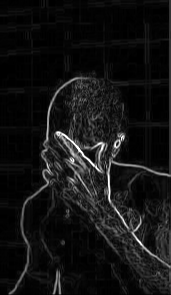

In [60]:
# https://en.wikipedia.org/wiki/Seam_carving
image = load("./assets/download.jpeg")

function edgeImageFunc(image)
    sy, sx = Kernel.sobel()
    grad_x = imfilter(image, sx)
    grad_y = imfilter(image, sy)
    edgeImage = hypot.(grad_x, grad_y)

    edge_norm = edgeImage ./ maximum(edgeImage)
    return Gray.(edge_norm)
end

function seamPixels(img)
    edgedOutImage = edgeImageFunc(img)

    (height, width) = size(edgedOutImage)

    energyImage = copy(edgedOutImage)

    for x in height:-1:1
        for y in width:-1:1
            if x == height
                energyImage[x, y] = edgedOutImage[x, y]
                continue
            end

            y_bottom = y
            y_bottom_left = clamp(y - 1, 1, width)
            y_bottom_right = clamp(y + 1, 1, width)

            leastArr = [edgedOutImage[(x+1), y_bottom] + edgedOutImage[x, y], edgedOutImage[(x+1), y_bottom] + edgedOutImage[x, y], edgedOutImage[(x+1), y_bottom] + edgedOutImage[x, y]]
            sort!(leastArr)

            energyImage[x, y] = leastArr[1]
        end
    end
    return energyImage
end

energyMap = seamPixels(image)

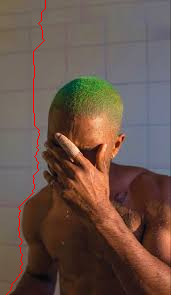

In [61]:
function traceSeamPixels(originalImage, energizedImage)
    (height, width) = size(energizedImage)
    
    tracedImage = RGB.(originalImage)
    
    _, minIndex = findmin(energizedImage[1, :])
    current_col = minIndex[1]

    for x in 1:height
        tracedImage[x, current_col] = RGB(1, 0, 0)
        
        if x == height
            break
        end
        
        c_left  = clamp(current_col - 1, 1, width)
        c_mid   = current_col
        c_right = clamp(current_col + 1, 1, width)
        
        e_left  = energizedImage[x + 1, c_left]
        e_mid   = energizedImage[x + 1, c_mid]
        e_right = energizedImage[x + 1, c_right]
        
        if e_left <= e_mid && e_left <= e_right
            current_col = c_left
        elseif e_mid <= e_left && e_mid <= e_right
            current_col = c_mid
        else
            current_col = c_right
        end
    end
    
    return tracedImage
end

tracedSeamImage = traceSeamPixels(image, energyMap)

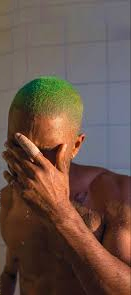

In [62]:
function resizeImage(originalImage, times)
    current_img = copy(originalImage)

    for i in 1:times
        energizedImage = seamPixels(current_img)
        
        (height, width) = size(energizedImage)
        
        _, minIndex = findmin(energizedImage[1, :])
        current_col = minIndex
        
        new_width = width - 1
        seam_carved_image = similar(current_img, height, new_width)
        
        for x in 1:height
            if current_col > 1
                seam_carved_image[x, 1:current_col-1] = current_img[x, 1:current_col-1]
            end
            
            if current_col < width
                seam_carved_image[x, current_col:new_width] = current_img[x, current_col+1:width]
            end
            
            if x < height
                c_left  = clamp(current_col - 1, 1, width)
                c_mid   = current_col
                c_right = clamp(current_col + 1, 1, width)
                
                e_left  = energizedImage[x + 1, c_left]
                e_mid   = energizedImage[x + 1, c_mid]
                e_right = energizedImage[x + 1, c_right]
                
                if e_left <= e_mid && e_left <= e_right
                    current_col = c_left
                elseif e_mid <= e_left && e_mid <= e_right
                    current_col = c_mid
                else
                    current_col = c_right
                end
            end
        end
        
        current_img = seam_carved_image
    end
    
    return current_img
end

croppedImage = resizeImage(image, 40)

In [63]:
println(size(image))
println(size(croppedImage))